Grasp Quality (Largest Minimum Wrench): 0.2360 N or Nm
Center of largest inscribed ball: [ 3.47687620e-18  3.65911729e-16 -1.24571923e-02]


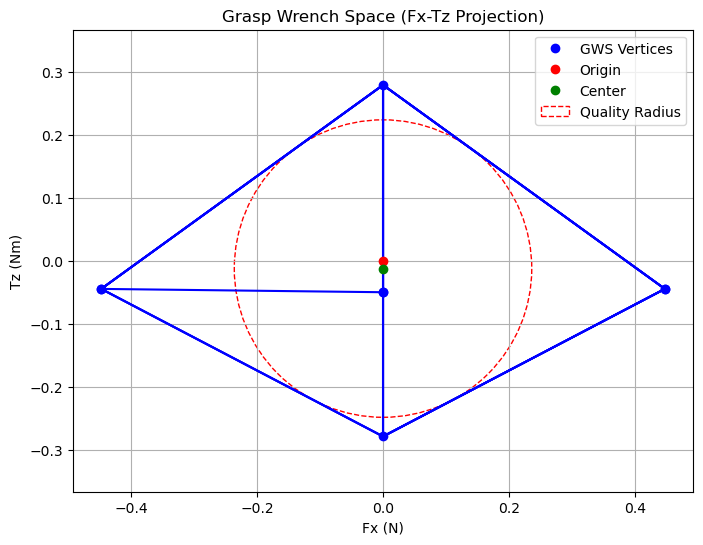

In [7]:
import numpy as np
import cvxpy as cp
import matplotlib.pyplot as plt
from scipy.spatial import ConvexHull

# Step 1: Define the gripper and object
contact1_pos = np.array([-0.05, 0])  # Left contact at (-5 cm, 0)
contact2_pos = np.array([0.05, 0])   # Right contact at (5 cm, 0)
mu = 0.5  # Friction coefficient

# Step 2: Define wrench basis for each contact
normal1 = np.array([0, 1])  # Inward normal for left contact
normal2 = np.array([0, -1]) # Inward normal for right contact
tangent = np.array([1, 0])  # Tangential direction

# Friction cone edges
f1_n = normal1
f1_t1 = normal1 + mu * tangent
f1_t2 = normal1 - mu * tangent
f2_n = normal2
f2_t1 = normal2 + mu * tangent
f2_t2 = normal2 - mu * tangent

# Normalize friction cone edges
f1_t1 /= np.linalg.norm(f1_t1)
f1_t2 /= np.linalg.norm(f1_t2)
f2_t1 /= np.linalg.norm(f2_t1)
f2_t2 /= np.linalg.norm(f2_t2)

# Wrench calculation
def wrench(pos, force):
    fx, fy = force
    tz = pos[0] * fy - pos[1] * fx
    return np.array([fx, fy, tz])

# Compute wrench basis
w1_n = wrench(contact1_pos, f1_n)
w1_t1 = wrench(contact1_pos, f1_t1)
w1_t2 = wrench(contact1_pos, f1_t2)
w2_n = wrench(contact2_pos, f2_n)
w2_t1 = wrench(contact2_pos, f2_t1)
w2_t2 = wrench(contact2_pos, f2_t2)

# Grasp matrix G
G = np.column_stack([w1_n, w1_t1, w1_t2, w2_n, w2_t1, w2_t2])

# Step 3: Compute Grasp Wrench Space vertices
vertices = []
for coeffs in np.eye(6):
    vertices.append(G @ coeffs)
for coeffs in [np.ones(6), -np.ones(6)]:
    vertices.append(G @ coeffs)
vertices = np.array(vertices)

# Approximate GWS as convex hull
hull = ConvexHull(vertices)

# Step 4: Quality metric - Largest inscribed ball (Chebyshev center)
w = cp.Variable(3)  # Center of the ball
r = cp.Variable()   # Radius of the ball
f = cp.Variable(6)  # Contact force coefficients

# Constraints: w lies in GWS, and r is the radius to the boundary
constraints = [
    w == G @ f,              # Wrench is a combination of basis
    cp.norm(f, 1) <= 1,      # Force limit
    f >= 0                   # Unilateral contacts
]

# Add constraints for each facet of the convex hull to ensure ball fits inside
for simplex in hull.equations:
    normal, offset = simplex[:-1], simplex[-1]
    constraints.append(cp.sum(normal @ w) + r * cp.norm(normal, 2) <= -offset)

# Objective: Maximize the radius
objective = cp.Maximize(r)
problem = cp.Problem(objective, constraints)
problem.solve()

quality = problem.value
print(f"Grasp Quality (Largest Minimum Wrench): {quality:.4f} N or Nm")
print(f"Center of largest inscribed ball: {w.value}")

# Step 5: Visualization (Fx vs Tz projection)
plt.figure(figsize=(8, 6))
plt.plot(vertices[:, 0], vertices[:, 2], 'bo', label='GWS Vertices')
for simplex in hull.simplices:
    plt.plot(vertices[simplex, 0], vertices[simplex, 2], 'b-')
plt.plot([0], [0], 'ro', label='Origin')
plt.plot([w.value[0]], [w.value[2]], 'go', label='Center')
circle = plt.Circle((w.value[0], w.value[2]), quality, color='r', fill=False, linestyle='--', label='Quality Radius')
plt.gca().add_artist(circle)
plt.xlabel('Fx (N)')
plt.ylabel('Tz (Nm)')
plt.title('Grasp Wrench Space (Fx-Tz Projection)')
plt.legend()
plt.grid(True)
plt.axis('equal')
plt.show()

In [50]:
import numpy as np
import cvxpy as cp
import plotly.graph_objects as go
from scipy.spatial import ConvexHull

# Step 1: Define the gripper and object (3D)
contact1_pos = np.array([1, 1, 0])   # Finger 1 (right face)
contact2_pos = np.array([-1, 1, 0])  # Finger 2 (left face)
contact3_pos = np.array([0, -1, 0])   # Thumb (top face)
mu = 0.5  # Friction coefficient

# Step 2: Define wrench basis for each contact
normal1 = np.array([-1, -1, 0])  # Right face, inward
normal2 = np.array([1, -1, 0])   # Left face, inward
normal3 = np.array([0, 1, 0])  # Top face, inward


# Contact 1 (Finger 1)
tangent1_a = np.array([0, 0, 1])
tangent1_b = np.array([1, -1, 0])

# Contact 2 (Finger 2)
tangent2_a = np.array([0, 0, 1])
tangent2_b = np.array([1, 1, 0])

# Contact 3 (Thumb)
tangent3_a = np.array([0, 0, 1])
tangent3_b = np.array([-1, 0, 0])

f1_n = normal1
f1_t1 = normal1 + mu * tangent1_a
f1_t2 = normal1 + mu * tangent1_b
f2_n = normal2
f2_t1 = normal2 + mu * tangent2_a
f2_t2 = normal2 + mu * tangent2_b
f3_n = normal3
f3_t1 = normal3 + mu * tangent3_a
f3_t2 = normal3 + mu * tangent3_b

f1_t1 /= np.linalg.norm(f1_t1)
f1_t2 /= np.linalg.norm(f1_t2)
f2_t1 /= np.linalg.norm(f2_t1)
f2_t2 /= np.linalg.norm(f2_t2)
f3_t1 /= np.linalg.norm(f3_t1)
f3_t2 /= np.linalg.norm(f3_t2)

def wrench(pos, force):
    r = pos
    f = force
    torque = np.cross(r, f)
    return np.concatenate([f, torque])

w1_n = wrench(contact1_pos, f1_n)
w1_t1 = wrench(contact1_pos, f1_t1)
w1_t2 = wrench(contact1_pos, f1_t2)
w2_n = wrench(contact2_pos, f2_n)
w2_t1 = wrench(contact2_pos, f2_t1)
w2_t2 = wrench(contact2_pos, f2_t2)
w3_n = wrench(contact3_pos, f3_n)
w3_t1 = wrench(contact3_pos, f3_t1)
w3_t2 = wrench(contact3_pos, f3_t2)



G = np.column_stack([w1_n, w1_t1, w1_t2, w2_n, w2_t1, w2_t2, w3_n, w3_t1, w3_t2])


# Step 3: Compute Grasp Wrench Space vertices
vertices = []
for coeffs in np.eye(9):
    vertices.append(G @ coeffs)
for coeffs in [np.ones(9), -np.ones(9)]:
    vertices.append(G @ coeffs)
vertices = np.array(vertices)

try:
    hull = ConvexHull(vertices)
except:
    print("Convex hull computation failed. Using vertices as-is.")
    hull = None

# Step 4: Quality metric - Largest inscribed ball
w = cp.Variable(6)
r = cp.Variable()
f = cp.Variable(9)

constraints = [
    w == G @ f,
    cp.norm(f, 1) <= 1,
    f >= 0
]

if hull:
    for simplex in hull.equations:
        normal, offset = simplex[:-1], simplex[-1]
        constraints.append(cp.sum(normal @ w) + r * cp.norm(normal, 2) <= -offset)

objective = cp.Maximize(r)
problem = cp.Problem(objective, constraints)
problem.solve()

quality = problem.value
print(f"Grasp Quality (Largest Minimum Wrench): {quality:.4f} N or Nm")
print(f"Center of largest inscribed ball: {w.value}")

# Step 5: Interactive 3D Plot with Plotly (Fx, Fy, Tz projection)
fig = go.Figure()

# GWS vertices
fig.add_trace(go.Scatter3d(
    x=vertices[:, 0], y=vertices[:, 1], z=vertices[:, 5],
    mode='markers', marker=dict(size=5, color='blue'),
    name='GWS Vertices'
))

# Origin
fig.add_trace(go.Scatter3d(
    x=[0], y=[0], z=[0],
    mode='markers', marker=dict(size=8, color='red'),
    name='Origin'
))

# Center of the ball

fig.add_trace(go.Scatter3d(
    x=[w.value[0]], y=[w.value[1]], z=[w.value[5]],
    mode='markers', marker=dict(size=8, color='green'),
    name='Center'
))


# Quality sphere (parametric)
u, v = np.mgrid[0:2*np.pi:20j, 0:np.pi:10j]
x = quality * np.cos(u) * np.sin(v) + w.value[0]
y = quality * np.sin(u) * np.sin(v) + w.value[1]
z = quality * np.cos(v) + w.value[5]
fig.add_trace(go.Surface(
    x=x, y=y, z=z,
    opacity=0.4,  # Slightly more visible but still see-through
    colorscale='Reds',
    showscale=False,
    name=f'Largest Minimum Wrench ({quality:.4f} N or Nm)',
    surfacecolor=np.ones_like(x),  # Uniform red
    contours=dict(
        x=dict(show=True, color='red', width=1),
        y=dict(show=True, color='red', width=1),
        z=dict(show=True, color='red', width=1)
    )  # Add wireframe-like contours
))

# Layout
fig.update_layout(
    title='Grasp Wrench Space (Fx-Fy-Tz Projection)',
    scene=dict(
        xaxis_title='Fx (N)',
        yaxis_title='Fy (N)',
        zaxis_title='Tz (Nm)',
        aspectmode='cube'
    ),
    legend=dict(yanchor="top", y=0.99, xanchor="left", x=0.01)
)

fig.show()

Grasp Quality (Largest Minimum Wrench): 0.1285 N or Nm
Center of largest inscribed ball: [ 1.05251700e-03 -3.55808523e-01  2.15949464e-01  7.22704632e-02
  3.37258334e-04 -1.47800301e-01]


In [33]:
import numpy as np
import cvxpy as cp
import plotly.graph_objects as go
from scipy.spatial import ConvexHull

# Function to compute wrench
def wrench(pos, force):
    r = pos
    f = force
    torque = np.cross(r, f)
    return np.concatenate([f, torque])

# Friction coefficient
mu = 0.5

# --- Parallel Gripper (2 soft-finger contacts) ---
p_contact1_pos = np.array([-0.05, 0, 0])  # Left face
p_contact2_pos = np.array([0.05, 0, 0])   # Right face

p_normal1 = np.array([1, 0, 0])   # Left face, inward
p_normal2 = np.array([-1, 0, 0])  # Right face, inward
p_tangent1_a = np.array([0, 1, 0])
p_tangent1_b = np.array([0, 0, 1])
p_tangent2_a = np.array([0, 1, 0])
p_tangent2_b = np.array([0, 0, 1])

# Soft-finger: normal + 2 tangents + torsional moment
p_f1_n = p_normal1
p_f1_t1 = p_normal1 + mu * p_tangent1_a
p_f1_t2 = p_normal1 + mu * p_tangent1_b
p_f1_torsion = np.array([0, 0, 1])  # Torsional moment along z
p_f2_n = p_normal2
p_f2_t1 = p_normal2 + mu * p_tangent2_a
p_f2_t2 = p_normal2 + mu * p_tangent2_b
p_f2_torsion = np.array([0, 0, 1])

p_f1_t1 /= np.linalg.norm(p_f1_t1)
p_f1_t2 /= np.linalg.norm(p_f1_t2)
p_f2_t1 /= np.linalg.norm(p_f2_t1)
p_f2_t2 /= np.linalg.norm(p_f2_t2)

p_w1_n = wrench(p_contact1_pos, p_f1_n)
p_w1_t1 = wrench(p_contact1_pos, p_f1_t1)
p_w1_t2 = wrench(p_contact1_pos, p_f1_t2)
p_w1_torsion = np.concatenate([np.zeros(3), p_f1_torsion * 0.01])  # Small torque scale
p_w2_n = wrench(p_contact2_pos, p_f2_n)
p_w2_t1 = wrench(p_contact2_pos, p_f2_t1)
p_w2_t2 = wrench(p_contact2_pos, p_f2_t2)
p_w2_torsion = np.concatenate([np.zeros(3), p_f2_torsion * 0.01])

# Grasp matrix (6 x 8, 4 wrenches per contact)
p_G = np.column_stack([p_w1_n, p_w1_t1, p_w1_t2, p_w1_torsion, p_w2_n, p_w2_t1, p_w2_t2, p_w2_torsion])

p_vertices = []
for coeffs in np.eye(8):
    p_vertices.append(p_G @ coeffs)
for coeffs in [np.ones(8), -np.ones(8)]:
    p_vertices.append(p_G @ coeffs)
p_vertices = np.array(p_vertices)

try:
    p_hull = ConvexHull(p_vertices)
except:
    print("Parallel gripper: Convex hull failed.")
    p_hull = None

p_w = cp.Variable(6)
p_r = cp.Variable()
p_f = cp.Variable(8)
p_constraints = [p_w == p_G @ p_f, cp.norm(p_f, 1) <= 1, p_f >= 0]
if p_hull:
    for simplex in p_hull.equations:
        normal, offset = simplex[:-1], simplex[-1]
        p_constraints.append(cp.sum(normal @ p_w) + p_r * cp.norm(normal, 2) <= -offset)
p_problem = cp.Problem(cp.Maximize(p_r), p_constraints)
p_problem.solve()
p_quality = p_problem.value if p_problem.status == cp.OPTIMAL else 0
print(f"Parallel Gripper Quality: {p_quality:.4f} N or Nm (Status: {p_problem.status})")

# --- Anthropomorphic Gripper (3 contacts) ---
contact1_pos = np.array([0.05, 0, 0])
contact2_pos = np.array([-0.05, 0, 0])
contact3_pos = np.array([0, 0, 0.05])

normal1 = np.array([-1, 0, 0])
normal2 = np.array([1, 0, 0])
normal3 = np.array([0, 0, -1])

tangent1_a = np.array([0, 1, 0])
tangent1_b = np.array([0, 0, 1])
tangent2_a = np.array([0, 1, 0])
tangent2_b = np.array([0, 0, 1])
tangent3_a = np.array([1, 0, 0])
tangent3_b = np.array([0, 1, 0])

f1_n = normal1
f1_t1 = normal1 + mu * tangent1_a
f1_t2 = normal1 + mu * tangent1_b
f2_n = normal2
f2_t1 = normal2 + mu * tangent2_a
f2_t2 = normal2 + mu * tangent2_b
f3_n = normal3
f3_t1 = normal3 + mu * tangent3_a
f3_t2 = normal3 + mu * tangent3_b

f1_t1 /= np.linalg.norm(f1_t1)
f1_t2 /= np.linalg.norm(f1_t2)
f2_t1 /= np.linalg.norm(f2_t1)
f2_t2 /= np.linalg.norm(f2_t2)
f3_t1 /= np.linalg.norm(f3_t1)
f3_t2 /= np.linalg.norm(f3_t2)

w1_n = wrench(contact1_pos, f1_n)
w1_t1 = wrench(contact1_pos, f1_t1)
w1_t2 = wrench(contact1_pos, f1_t2)
w2_n = wrench(contact2_pos, f2_n)
w2_t1 = wrench(contact2_pos, f2_t1)
w2_t2 = wrench(contact2_pos, f2_t2)
w3_n = wrench(contact3_pos, f3_n)
w3_t1 = wrench(contact3_pos, f3_t1)
w3_t2 = wrench(contact3_pos, f3_t2)

G = np.column_stack([w1_n, w1_t1, w1_t2, w2_n, w2_t1, w2_t2, w3_n, w3_t1, w3_t2])

vertices = []
for coeffs in np.eye(9):
    vertices.append(G @ coeffs)
for coeffs in [np.ones(9), -np.ones(9)]:
    vertices.append(G @ coeffs)
vertices = np.array(vertices)

try:
    hull = ConvexHull(vertices)
except:
    print("Anthropomorphic gripper: Convex hull failed.")
    hull = None

w = cp.Variable(6)
r = cp.Variable()
f = cp.Variable(9)
constraints = [w == G @ f, cp.norm(f, 1) <= 1, f >= 0]
if hull:
    for simplex in hull.equations:
        normal, offset = simplex[:-1], simplex[-1]
        constraints.append(cp.sum(normal @ w) + r * cp.norm(normal, 2) <= -offset)
problem = cp.Problem(cp.Maximize(r), constraints)
problem.solve()
quality = problem.value if problem.status == cp.OPTIMAL else 0
print(f"Anthropomorphic Gripper Quality: {quality:.4f} N or Nm (Status: {problem.status})")

# Plot both (Fx, Fy, Tz projection)
fig = go.Figure()

# Parallel Gripper
fig.add_trace(go.Scatter3d(
    x=p_vertices[:, 0], y=p_vertices[:, 1], z=p_vertices[:, 5],
    mode='markers', marker=dict(size=5, color='blue'),
    name='Parallel GWS Vertices'
))
if p_quality > 0:
    fig.add_trace(go.Scatter3d(
        x=[p_w.value[0]], y=[p_w.value[1]], z=[p_w.value[5]],
        mode='markers', marker=dict(size=8, color='cyan'),
        name='Parallel Center'
    ))
    u, v = np.mgrid[0:2*np.pi:20j, 0:np.pi:10j]
    x = p_quality * np.cos(u) * np.sin(v) + p_w.value[0]
    y = p_quality * np.sin(u) * np.sin(v) + p_w.value[1]
    z = p_quality * np.cos(v) + p_w.value[5]
    fig.add_trace(go.Surface(
        x=x, y=y, z=z, opacity=0.3, colorscale='Blues', showscale=False,
        name='Parallel Quality Sphere'
    ))

# Anthropomorphic Gripper
fig.add_trace(go.Scatter3d(
    x=vertices[:, 0], y=vertices[:, 1], z=vertices[:, 5],
    mode='markers', marker=dict(size=5, color='red'),
    name='Anthro GWS Vertices'
))
if quality > 0:
    fig.add_trace(go.Scatter3d(
        x=[w.value[0]], y=[w.value[1]], z=[w.value[5]],
        mode='markers', marker=dict(size=8, color='orange'),
        name='Anthro Center'
    ))
    x = quality * np.cos(u) * np.sin(v) + w.value[0]
    y = quality * np.sin(u) * np.sin(v) + w.value[1]
    z = quality * np.cos(v) + w.value[5]
    fig.add_trace(go.Surface(
        x=x, y=y, z=z, opacity=0.3, colorscale='Reds', showscale=False,
        name='Anthro Quality Sphere'
    ))

# Origin
fig.add_trace(go.Scatter3d(
    x=[0], y=[0], z=[0],
    mode='markers', marker=dict(size=8, color='black'),
    name='Origin'
))

fig.update_layout(
    title='Parallel vs Anthropomorphic Gripper (Fx-Fy-Tz)',
    scene=dict(
        xaxis_title='Fx (N)',
        yaxis_title='Fy (N)',
        zaxis_title='Tz (Nm)',
        aspectmode='cube'
    ),
    legend=dict(yanchor="top", y=0.99, xanchor="left", x=0.01)
)

fig.show()

Parallel gripper: Convex hull failed.
Parallel Gripper Quality: 0.0000 N or Nm (Status: unbounded)
Anthropomorphic Gripper Quality: 0.0057 N or Nm (Status: optimal)


In [49]:
# Step 1: Define the gripper and object (3D)
contact1_pos = np.array([1, 1, 0])   # Finger 1 (right face)
contact2_pos = np.array([-1, 1, 0])  # Finger 2 (left face)
contact3_pos = np.array([-1, -1, 0])   # Thumb (top face)
contact4_pos = np.array([1, -1, 0])
mu = 0.5  # Friction coefficient

# Step 2: Define wrench basis for each contact
normal1 = np.array([-1, -1, 0])  # Right face, inward
normal2 = np.array([1, -1, 0])   # Left face, inward
normal3 = np.array([1, 1, 0])  # Top face, inward
normal4 = np.array([-1, 1, 0]) 

# Contact 1 (Finger 1)
tangent1_a = np.array([0, 0, 1])
tangent1_b = np.array([1, -1, 0])

# Contact 2 (Finger 2)
tangent2_a = np.array([0, 0, 1])
tangent2_b = np.array([1, 1, 0])

# Contact 3 (Thumb)
tangent3_a = np.array([0, 0, 1])
tangent3_b = np.array([-1, 1, 0])

# Contact 4
tangent4_a = np.array([0, 0, 1])
tangent4_b = np.array([-1, -1, 0])
f1_n = normal1
f1_t1 = normal1 + mu * tangent1_a
f1_t2 = normal1 + mu * tangent1_b
f2_n = normal2
f2_t1 = normal2 + mu * tangent2_a
f2_t2 = normal2 + mu * tangent2_b
f3_n = normal3
f3_t1 = normal3 + mu * tangent3_a
f3_t2 = normal3 + mu * tangent3_b
f4_n = normal4
f4_t1 = normal4 + mu * tangent4_a
f4_t2 = normal4 + mu * tangent4_b

f1_t1 /= np.linalg.norm(f1_t1)
f1_t2 /= np.linalg.norm(f1_t2)
f2_t1 /= np.linalg.norm(f2_t1)
f2_t2 /= np.linalg.norm(f2_t2)
f3_t1 /= np.linalg.norm(f3_t1)
f3_t2 /= np.linalg.norm(f3_t2)
f4_t1 /= np.linalg.norm(f4_t1)
f4_t2 /= np.linalg.norm(f4_t2)

def wrench(pos, force):
    r = pos
    f = force
    torque = np.cross(r, f)
    return np.concatenate([f, torque])

w1_n = wrench(contact1_pos, f1_n)
w1_t1 = wrench(contact1_pos, f1_t1)
w1_t2 = wrench(contact1_pos, f1_t2)
w2_n = wrench(contact2_pos, f2_n)
w2_t1 = wrench(contact2_pos, f2_t1)
w2_t2 = wrench(contact2_pos, f2_t2)
w3_n = wrench(contact3_pos, f3_n)
w3_t1 = wrench(contact3_pos, f3_t1)
w3_t2 = wrench(contact3_pos, f3_t2)
w4_n = wrench(contact4_pos, f4_n)
w4_t1 = wrench(contact4_pos, f4_t1)
w4_t2 = wrench(contact4_pos, f4_t2)



G = np.column_stack([w1_n, w1_t1, w1_t2, w2_n, w2_t1, w2_t2, w3_n, w3_t1, w3_t2, w4_n, w4_t1, w4_t2])


# Step 3: Compute Grasp Wrench Space vertices
vertices = []
for coeffs in np.eye(12):
    vertices.append(G @ coeffs)
for coeffs in [np.ones(12), -np.ones(12)]:
    vertices.append(G @ coeffs)
vertices = np.array(vertices)

try:
    hull = ConvexHull(vertices)
except:
    print("Convex hull computation failed. Using vertices as-is.")
    hull = None

# Step 4: Quality metric - Largest inscribed ball
w = cp.Variable(6)
r = cp.Variable()
f = cp.Variable(12)

constraints = [
    w == G @ f,
    cp.norm(f, 1) <= 1,
    f >= 0
]

if hull:
    for simplex in hull.equations:
        normal, offset = simplex[:-1], simplex[-1]
        constraints.append(cp.sum(normal @ w) + r * cp.norm(normal, 2) <= -offset)

objective = cp.Maximize(r)
problem = cp.Problem(objective, constraints)
problem.solve()

quality = problem.value
print(f"Grasp Quality (Largest Minimum Wrench): {quality:.4f} N or Nm")
print(f"Center of largest inscribed ball: {w.value}")

# Step 5: Interactive 3D Plot with Plotly (Fx, Fy, Tz projection)
fig = go.Figure()

# GWS vertices
#fig.add_trace(go.Scatter3d(
 #   x=vertices[:, 0], y=vertices[:, 1], z=vertices[:, 5],
  #  mode='markers', marker=dict(size=5, color='blue'),
   # name='GWS Vertices'
#))

# Origin
fig.add_trace(go.Scatter3d(
    x=[0], y=[0], z=[0],
    mode='markers', marker=dict(size=8, color='red'),
    name='Origin'
))

# Center of the ball

fig.add_trace(go.Scatter3d(
    x=[w.value[0]], y=[w.value[1]], z=[w.value[5]],
    mode='markers', marker=dict(size=8, color='green'),
    name='Center'
))


# Quality sphere (parametric)
u, v = np.mgrid[0:2*np.pi:20j, 0:np.pi:10j]
x = quality * np.cos(u) * np.sin(v) + w.value[0]
y = quality * np.sin(u) * np.sin(v) + w.value[1]
z = quality * np.cos(v) + w.value[5]
fig.add_trace(go.Surface(
    x=x, y=y, z=z,
    opacity=0.4,  # Slightly more visible but still see-through
    colorscale='Reds',
    showscale=False,
    name=f'Largest Minimum Wrench ({quality:.4f} N or Nm)',
    surfacecolor=np.ones_like(x),  # Uniform red
    contours=dict(
        x=dict(show=True, color='red', width=1),
        y=dict(show=True, color='red', width=1),
        z=dict(show=True, color='red', width=1)
    )  # Add wireframe-like contours
))

# Layout
fig.update_layout(
    title='Grasp Wrench Space (Fx-Fy-Tz Projection)',
    scene=dict(
        xaxis_title='Fx (N)',
        yaxis_title='Fy (N)',
        zaxis_title='Tz (Nm)',
        aspectmode='cube'
    ),
    legend=dict(yanchor="top", y=0.99, xanchor="left", x=0.01)
)

fig.show()

Grasp Quality (Largest Minimum Wrench): 0.1754 N or Nm
Center of largest inscribed ball: [ 1.27744669e-10 -8.85685671e-11  1.30707641e-01  1.89561708e-11
  1.99099336e-11 -6.80077864e-02]
